# Scrapping Indicators Data

In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Reporteros Sin Fronteras (RSF - Reporters Without Borders) 

In [3]:
import requests
import pandas as pd
import os
from io import StringIO  # Import StringIO

# URL to fetch the request table from
url = "https://rsf.org/en/index?year="

# List of years to iterate over
years = [str(year) for year in range(2002, 2024) if year != 2011]

# Function to get the request table from a given URL
def get_request_table(year):
    year_url = f"{url}{year}"
    response = requests.get(year_url)
    response.raise_for_status()  # Raise an error for bad responses
    
    # Use StringIO to convert the response text to a file-like object
    html_content = StringIO(response.text)
    
    # Get the first table on the page and return it as a DataFrame
    return pd.read_html(html_content)[0]

# Create a DataFrame to hold all the tables for the years
all_data = pd.DataFrame()

# Loop through the years and fetch the tables
for year in years:
    try:
        data = get_request_table(year)
        data['Year'] = year  # Add the year as a column to the data
        all_data = pd.concat([all_data, data], ignore_index=True)
    except Exception as e:
        print(f"Could not retrieve data for {year}: {e}")

# Clean the DataFrame
# 1. Keep only the necessary columns (Country, Year, Global score)
clean_data = all_data[['Countries', 'Year', 'Global score']].copy()

# 2. Rename columns for consistency
clean_data.columns = ['country', 'year', 'wpf_score']

# 3. Normalize the 'wpf_score' to values between 0 and 1
clean_data['wpf_score'] = (clean_data['wpf_score'] - clean_data['wpf_score'].min()) / (clean_data['wpf_score'].max() - clean_data['wpf_score'].min())

# Specify the directory where the CSV should be saved
save_dir = '../data/processed/3_indicators'

# Make sure the directory exists, if not create it
os.makedirs(save_dir, exist_ok=True)

# Save the cleaned data to a CSV file
csv_filename = os.path.join(save_dir, 'wpf_scores.csv')
clean_data.to_csv(csv_filename, index=False)

print(f"Data saved to {csv_filename}")


Data saved to ../data/processed/3_indicators/wpf_scores.csv


# Preparing data

In [4]:
# Existing imports and path setup...
import pandas as pd
import json
import os

In [5]:
# Paths
raw_data_path = "../data/raw"
polarisation_path = "../data/reports/polarisation_scores/"
wpf_path = "../data/processed/3_indicators"
output_path = "../data/processed/3_indicators"
os.makedirs(output_path, exist_ok=True)

In [30]:
# === ACLED EVENTS & FATALITIES ===

# Load ISO mapping
with open("iso_country.json") as f:
    iso_mapping = json.load(f)
iso_df = pd.DataFrame.from_dict(iso_mapping, orient='index').reset_index()
iso_df.columns = ['iso_code', 'country']


# ===== Load ACLED data =====

# Read "results" sheet from the Excel file
conflict = pd.read_excel(os.path.join(raw_data_path, "acled_2024_conflict_ranking.xlsx"), sheet_name="Results")

# Rename columns to match
conflict = conflict.rename(columns={"Country": "country", "Index Ranking December 2024": "conflict_ranking"})

# Merge with ISO mapping based on country names
conflict = conflict.merge(iso_df, on="country", how="left")

# Add year (assuming same year for all rows; change if dynamic)
conflict["year"] = 2024

# Reorder columns so that iso_code is right after country

cols = conflict.columns.tolist()
cols.remove("iso_code")
cols.insert(cols.index("country") + 1, "iso_code")
conflict = conflict[cols]

### Keep only relevant columns "country", "iso_code", "year", "conflict_ranking"
conflict = conflict[["country", "iso_code", "year", "conflict_ranking"]]

### Drop rows with missing ISO codes
conflict = conflict.dropna(subset=["iso_code"])

# === E-GOV DATA ===

egov = pd.read_csv(os.path.join(raw_data_path, "egov_un_data.csv"))
egov = egov.rename(columns={
    "Country Name": "country",
    "E-Participation Index": "e_participation_index",
    "Survey Year": "year"
})

# Keep only relevant columns
egov = egov[["country", "e_participation_index", "year"]]

# Clean country names before merging
egov["country"] = (
    egov["country"]
    .str.strip()
    .str.replace('"', '')
    .str.replace(r'\s+', ' ', regex=True)
)

# Manual corrections
manual_corrections = {
    "Iran (Islamic Republic of)": "Iran",
    "Viet Nam": "Vietnam",
    "Türkiye": "Turkey",
    "United States of America": "United States",
    "Russian Federation": "Russia",
    "Republic of Korea": "South Korea",
}
egov["country"] = egov["country"].replace(manual_corrections)

# Now merge after cleaning
egov = egov.merge(iso_df, on="country", how="left")

# Reorder columns so that iso_code is right after country
cols = egov.columns.tolist()
cols.remove("iso_code")
cols.insert(cols.index("country") + 1, "iso_code")
egov = egov[cols]

# === FREEDOM ON THE NET DATA ===
freedom = pd.read_excel(
    os.path.join(raw_data_path, "freedom_net_country_score_data.xlsx"),
    skiprows=1,
    engine="openpyxl"  # Make sure openpyxl is installed
)
freedom = freedom.rename(columns={
    "Country": "country",
    "Edition": "year",
    "Total": "media_freedom_score"
})
freedom = freedom[["country", "year", "media_freedom_score"]]
freedom = freedom.merge(iso_df, on="country", how="left")
freedom = freedom.dropna(subset=["iso_code"])

# Reorder columns so that iso_code is right after country
cols = freedom.columns.tolist()
cols.remove("iso_code")
cols.insert(cols.index("country") + 1, "iso_code")
freedom = freedom[cols]

# === POLARISATION SCORES ===
polarisation = pd.read_csv(os.path.join(polarisation_path, "merged_polarization_scores.csv"))

# Clean column names
polarisation = polarisation.rename(columns={"country": "iso_code"})
polarisation = polarisation.rename(columns={"country_full": "country"})

# Move 'country' to the first column
cols = ['country'] + [col for col in polarisation.columns if col != 'country']
polarisation = polarisation[cols]

# === 🆕 WPF SCORES ===

wpf = pd.read_csv(os.path.join(wpf_path, "wpf_scores.csv"))

# Manual corrections
manual_corrections = {
    "Türkiye": "Turkey",
    "Morocco / Western Sahara": "Morocco",
}
wpf["country"] = wpf["country"].replace(manual_corrections)

# Merge ISO codes using the iso_df mapping
wpf = wpf.merge(iso_df, on="country", how="left")

# Drop rows with missing ISO codes
wpf = wpf.dropna(subset=["iso_code"])

# Reorder columns so that iso_code is right after country
cols = wpf.columns.tolist()
cols.remove("iso_code")
cols.insert(cols.index("country") + 1, "iso_code")
wpf = wpf[cols]

# === Tertiary Enrollment Education ===

education = pd.read_csv(os.path.join(raw_data_path, "tertiary_enrollment_wb.csv"))

# Clean column names
education = education.rename(columns={"Country Name": "country", "Country Code": "iso_code"})

# Manual corrections
manual_corrections = {
    "Iran, Islamic Rep.": "Iran",
    "Viet Nam": "Vietnam",
    "Turkiye": "Turkey",
    "United States of America": "United States",
    "Russian Federation": "Russia",
    "Korea, Rep.": "South Korea",
    "Kyrgyz Republic" : "Kyrgyzstan",
    "Hong Kong SAR, China": "Hong Kong",
    "Egypt, Arab Rep.": "Egypt",
}
education["country"] = education["country"].replace(manual_corrections)

# Drop unused columns
education = education.drop(columns=["Series Name", "Series Code"])

# Melt the DataFrame to long format
education = education.melt(
    id_vars=["country", "iso_code"],
    var_name="year",
    value_name="enrollment_percentage"
)

# Clean up the year column: extract only the year (e.g., from "2020 [YR2020]" to 2020)
education["year"] = education["year"].str.extract(r'(\d{4})').astype("Int64")

# Create a list of valid country names from the values of the JSON
valid_countries = list(iso_mapping.values())

# Filter to only include countries in the ISO mapping
education = education[education["country"].isin(valid_countries)]

# Final column order (optional but clean)
education = education[["country", "iso_code", "year", "enrollment_percentage"]]

# Clean enrollment_percentage early
education["enrollment_percentage"] = (
    pd.to_numeric(education["enrollment_percentage"], errors="coerce")
)

# === Democracy Index ===

democracy = pd.read_csv(os.path.join(raw_data_path, "democracy_index_eiu.csv"))

# Clean column names
democracy = democracy.rename(columns={"Entity": "country", "Code": "iso_code", "Year": "year", "Democracy score": "democracy_score"})

# Drop iso codes not in ISO mapping
democracy = democracy[democracy["iso_code"].isin(iso_df["iso_code"])]

# === Population Size ===


# === FINAL MERGE ===
df = pd.merge(conflict, egov, on=["country", "iso_code", "year"], how="outer")
df = pd.merge(df, freedom, on=["country", "iso_code", "year"], how="outer")
df = pd.merge(df, polarisation, on=["country", "iso_code", "year"], how="outer")
df = pd.merge(df, wpf, on=["country", "iso_code", "year"], how="outer")  
df = pd.merge(df, education, on=["country", "iso_code", "year"], how="outer")
df = pd.merge(df, democracy, on=["country", "iso_code", "year"], how="outer")

# Reorder columns: put 'iso_code' and 'year' together, followed by other columns
columns_order = ['country', 'iso_code', 'year'] + [col for col in df.columns if col not in ['country', 'iso_code', 'year']]
df = df[columns_order]

# drop columns mean, ci_low, ci_high
df = df.drop(columns=["mean", "ci_low", "ci_high", "polarization_zscore"], errors='ignore')

# drop waves 4 and 5
df = df[~df['wave'].isin([4, 5])]

# === SAVE OUTPUT ===
output_file = os.path.join(output_path, "misinformation_vulnerability_risk_index.csv")
df.to_csv(output_file, index=False)


## Building the Misinformation Vulnerability Index

In [31]:
# Load the misinformation index data
df = pd.read_csv("../data/processed/3_indicators/misinformation_vulnerability_risk_index.csv")

In [32]:
### === Misinformation Index ===

# Load the misinformation index data
df = pd.read_csv("../data/processed/3_indicators/misinformation_vulnerability_risk_index.csv")

# Variables we want to keep the most recent values for
target_vars = [
    "conflict_ranking", "e_participation_index", "media_freedom_score",
    "wave", "polarization_score", "wpf_score",
    "enrollment_percentage"]

# This function will return the most recent non-null value for a column
def get_latest_value(group, column):
    non_null_values = group.dropna(subset=[column])
    if non_null_values.empty:
        return pd.NA
    else:
        return non_null_values.sort_values("year", ascending=False).iloc[0][column]
    
# Build the result
rows = []
for country, group in df.groupby("country"):
    row = {
        "country": country,
        "iso_code": group["iso_code"].iloc[0]  # Assuming iso_code is constant per country
    }
    for col in target_vars:
        row[col] = get_latest_value(group, col)
    rows.append(row)

# Final DataFrame
result_df = pd.DataFrame(rows)

# Delete wave column
result_df = result_df.drop(columns=["wave"], errors='ignore')

# ======= Bye HKG Territory and Taiwan ==========

# Remove Hong Kong and Taiwan rows
result_df = result_df[result_df["country"] != "Hong Kong"]
result_df = result_df[result_df["country"] != "Taiwan"]

### Save as 'clean_misinformation_features.csv' in the reports, misinformation_indes directory
save_dir = '../data/reports/misinformation_index'
os.makedirs(save_dir, exist_ok=True)
result_df.to_csv(os.path.join(save_dir, "clean_misinformation_features.csv"), index=False)

# Check shape
print(result_df.shape)  # Should be (43, 15)

(41, 8)


# Standarizing Data

## Normalization

In [33]:
import pandas as pd

# Load your data
df = pd.read_csv("../data/reports/misinformation_index/clean_misinformation_features.csv")

# Convert relevant columns to float
numeric_columns = [
    'conflict_ranking',
    'e_participation_index',
    'media_freedom_score',
    'polarization_score',
    'wpf_score',
    'enrollment_percentage']

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 2: Reverse where needed
columns_to_reverse = ['conflict_ranking', 'polarization_score']
reversed_columns = []

for col in columns_to_reverse:
    reversed_col = f'{col}_rev'
    df[reversed_col] = df[col].max(skipna=True) - df[col]
    reversed_columns.append(reversed_col)

# Step 3: Normalize each column (original or reversed)
columns_to_normalize = {
    'conflict_ranking': 'conflict_ranking_rev',
    'e_participation_index': 'e_participation_index',
    'media_freedom_score': 'media_freedom_score',
    'polarization_score': 'polarization_score_rev',
    'wpf_score': 'wpf_score',
    'enrollment_percentage': 'enrollment_percentage'} 
    # 'democracy_score': 'democracy_score'}

normalized_columns = []

for name, col in columns_to_normalize.items():
    norm_col = f'{name}_norm'
    min_val = df[col].min(skipna=True)
    max_val = df[col].max(skipna=True)

    # Avoid divide-by-zero
    if min_val == max_val:
        df[norm_col] = 0.0
       
    else:
        df[norm_col] = (df[col] - min_val) / (max_val - min_val)

    normalized_columns.append(norm_col)

# Step 4: Preview results
cols_to_show = ['country', 'iso_code'] + numeric_columns + reversed_columns + normalized_columns
final_df = df[cols_to_show]

# Create a new DataFrame with only the normalized columns
norm_cols = [col for col in final_df.columns if col.endswith('_norm')]

# Include 'country' and 'iso_code' along with the normalized columns
final_df_norm = final_df[['country', 'iso_code'] + norm_cols]

# Print column names
print("Normalized columns:")
print(final_df_norm.columns.tolist())

Normalized columns:
['country', 'iso_code', 'conflict_ranking_norm', 'e_participation_index_norm', 'media_freedom_score_norm', 'polarization_score_norm', 'wpf_score_norm', 'enrollment_percentage_norm']


In [34]:
final_df_norm.head(50)

,country,iso_code,conflict_ranking_norm,e_participation_index_norm,media_freedom_score_norm,polarization_score_norm,wpf_score_norm,enrollment_percentage_norm
0,Argentina,ARG,0.434783,0.590864,0.805195,0.535477,0.773090,0.825801
1,Australia,AUS,0.204969,0.848468,0.870130,0.536320,0.847959,0.818953
2,Brazil,BRA,0.987578,0.848468,0.727273,0.496506,0.547714,0.429912
3,Canada,CAN,0.124224,0.909081,1.000000,0.379906,0.929119,0.573506
4,Chile,CHL,0.701863,0.818162,1.000000,0.346666,0.569500,0.760376
5,China,CHN,0.645963,0.924234,0.000000,0.529266,0.000000,0.552377
6,Colombia,COL,0.962733,0.712089,0.727273,0.622325,0.341516,0.420574
7,Cyprus,CYP,0.515528,0.666630,NaN,0.388728,0.700368,0.751614
8,Egypt,EGY,0.534161,0.545404,0.246753,1.000000,0.159558,0.251656
9,Germany,DEU,0.627329,0.969694,0.883117,0.627316,0.904265,0.573946


### Check for missing values

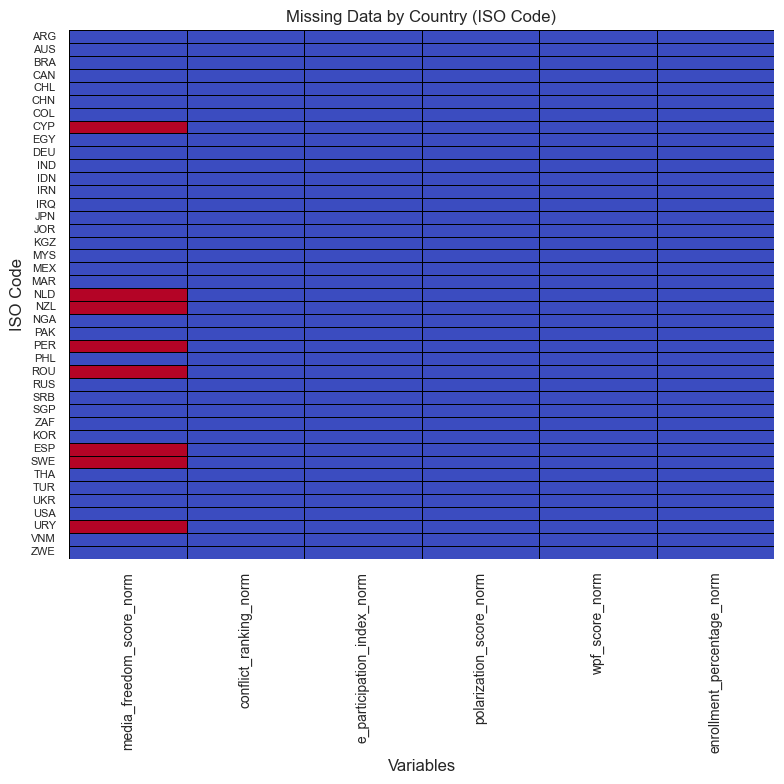

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define target variables
target_vars = [
    "media_freedom_score_norm","conflict_ranking_norm", "e_participation_index_norm",
    "polarization_score_norm", "wpf_score_norm",
    "enrollment_percentage_norm"] #, "democracy_score_norm"]

plot_vars = [var for var in target_vars if var in final_df_norm.columns]

# Select only the columns you care about
data_to_plot = final_df_norm.set_index("iso_code")[plot_vars]

# Plot missing data heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(data_to_plot.isna(), cbar=False, cmap="coolwarm", yticklabels=True, linewidths=0.5, linecolor='black')

# Font size adjustments for y tick labels
plt.yticks(fontsize=8)
plt.xticks(fontsize=10)

plt.title("Missing Data by Country (ISO Code)")
plt.xlabel("Variables")
plt.ylabel("ISO Code")
plt.tight_layout()
plt.show()

# Dealing with Missing Values

In [36]:
# ===== Adding the Region and Democracy Type for Average Imputation Purposes =====

import pandas as pd
import json

# Load Region mapping
with open("region_map.json", "r") as f:
    region_mapping = json.load(f)
region_df = pd.DataFrame(list(region_mapping.items()), columns=["iso_code", "region"])

# Load Democracy Type mapping
with open("democracy_type.json", "r") as f:
    democracy_mapping = json.load(f)
democracy_df = pd.DataFrame(list(democracy_mapping.items()), columns=["iso_code", "democracy_t"])

# Merge both columns into final_df_norm
final_df_norm = final_df_norm.merge(region_df, on="iso_code", how="left")
final_df_norm = final_df_norm.merge(democracy_df, on="iso_code", how="left")

# Reordering columns to have them at the beginning
cols = final_df_norm.columns.tolist()
if "region" in cols and "democracy_t" in cols:
    if "region" in cols:
        cols.remove("region")
    if "democracy_t" in cols:
        cols.remove("democracy_t")
    
    # Insert 'region' after 'iso_code' and 'democracy_t' after 'region'
    insert_at_region = cols.index("iso_code") + 1
    cols.insert(insert_at_region, "region")
    insert_at_democracy = cols.index("region") + 1
    cols.insert(insert_at_democracy, "democracy_t")
    final_df_norm = final_df_norm[cols]

print(final_df_norm.columns)

Index(['country', 'iso_code', 'region', 'democracy_t', 'conflict_ranking_norm',
       'e_participation_index_norm', 'media_freedom_score_norm',
       'polarization_score_norm', 'wpf_score_norm',
       'enrollment_percentage_norm'],
      dtype='object')


# Imputing Missing Values

### Using Artificial Data from Regional Means and Democracy Type

In [37]:
def impute_by_group_mean(df, group_col, cols_to_impute, countries_to_inspect):
    """
    Imputes missing values in specified columns using the mean within groups,
    and returns rows for selected countries.

    Parameters:
    - df: pandas DataFrame
    - group_col: column name to group by ('region' or 'democracy_t')
    - cols_to_impute: list of column names to impute
    - countries_to_inspect: list of iso_codes to filter the final output

    Returns:
    - imputed_values: DataFrame filtered by countries_to_inspect
    - missing_check: count of remaining missing values in imputed columns
    """
    df_copy = final_df_norm.copy()

    for col in cols_to_impute:
        df_copy[col] = df_copy.groupby(group_col)[col].transform(
            lambda x: x.fillna(x.mean())
        )

    # Check remaining missing values
    missing_check = df_copy[cols_to_impute].isnull().sum()

    # Filter by countries
    imputed_values = df_copy[df_copy["iso_code"].isin(countries_to_inspect)]

    return imputed_values, missing_check

In [38]:
def get_combined_media_freedom(df, group_col_1, group_col_2, cols_to_impute, countries_to_impute):
    imputed_1, _ = impute_by_group_mean(df, group_col_1, cols_to_impute, countries_to_impute)
    imputed_2, _ = impute_by_group_mean(df, group_col_2, cols_to_impute, countries_to_impute)

    merged = imputed_1[["iso_code", cols_to_impute[0]]].merge(
        imputed_2[["iso_code", cols_to_impute[0]]],
        on="iso_code",
        suffixes=(f"_{group_col_1}", f"_{group_col_2}")
    )

    merged["media_freedom_score_norm_combined"] = merged[
        [f"{cols_to_impute[0]}_{group_col_1}", f"{cols_to_impute[0]}_{group_col_2}"]
    ].mean(axis=1)

    return merged[["iso_code", "media_freedom_score_norm_combined"]]


##  Apply Combined Imputation to Missing Countries Only

# Identify countries where media_freedom_score_norm is missing
missing_countries = final_df_norm[final_df_norm["media_freedom_score_norm"].isnull()]["iso_code"].tolist()

In [39]:
# Get combined imputation only for those countries
combined_imputed_scores = get_combined_media_freedom(
    df=final_df_norm,
    group_col_1="region",
    group_col_2="democracy_t",
    cols_to_impute=["media_freedom_score_norm"],
    countries_to_impute=missing_countries
)

# Make a copy of your full df
df_combined = final_df_norm.copy()

# Merge the combined imputed values
df_combined = df_combined.merge(combined_imputed_scores, on="iso_code", how="left")

# Where media_freedom_score_norm is null, fill with the combined version
df_combined["media_freedom_score_norm"] = df_combined["media_freedom_score_norm"].fillna(
    df_combined["media_freedom_score_norm_combined"]
)

# Drop the helper column
df_combined.drop(columns=["media_freedom_score_norm_combined"], inplace=True)

# Correlations

### Correlation Matrix: Average Means Imputation With Artifitial Data

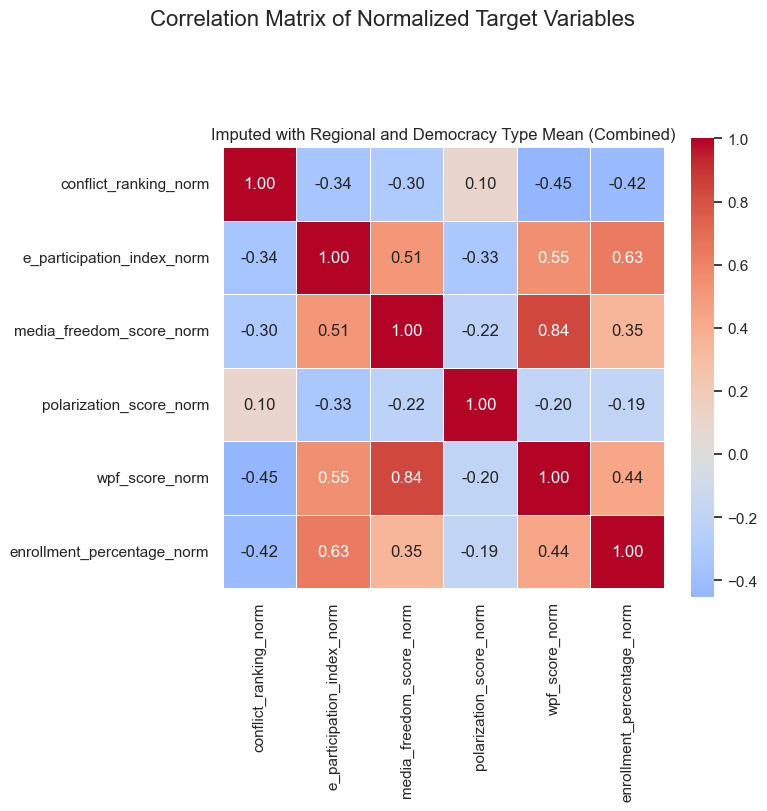

In [134]:
## Build the Correlation Matrix

target_vars = [
    "conflict_ranking_norm", "e_participation_index_norm", "media_freedom_score_norm",
    "polarization_score_norm", "wpf_score_norm", "enrollment_percentage_norm"
]

# Drop rows with any missing values among the variables
df_corr = df_combined[target_vars].apply(pd.to_numeric, errors='coerce').dropna()

# Compute and plot correlation matrix
plt.figure(figsize=(8, 8))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    fmt=".2f",
    cbar_kws={"shrink": 0.8}
)
plt.suptitle("Correlation Matrix of Normalized Target Variables", fontsize=16, y=1.02)
plt.title("Imputed with Regional and Democracy Type Mean (Combined)", fontsize=12)
plt.tight_layout()
plt.show()

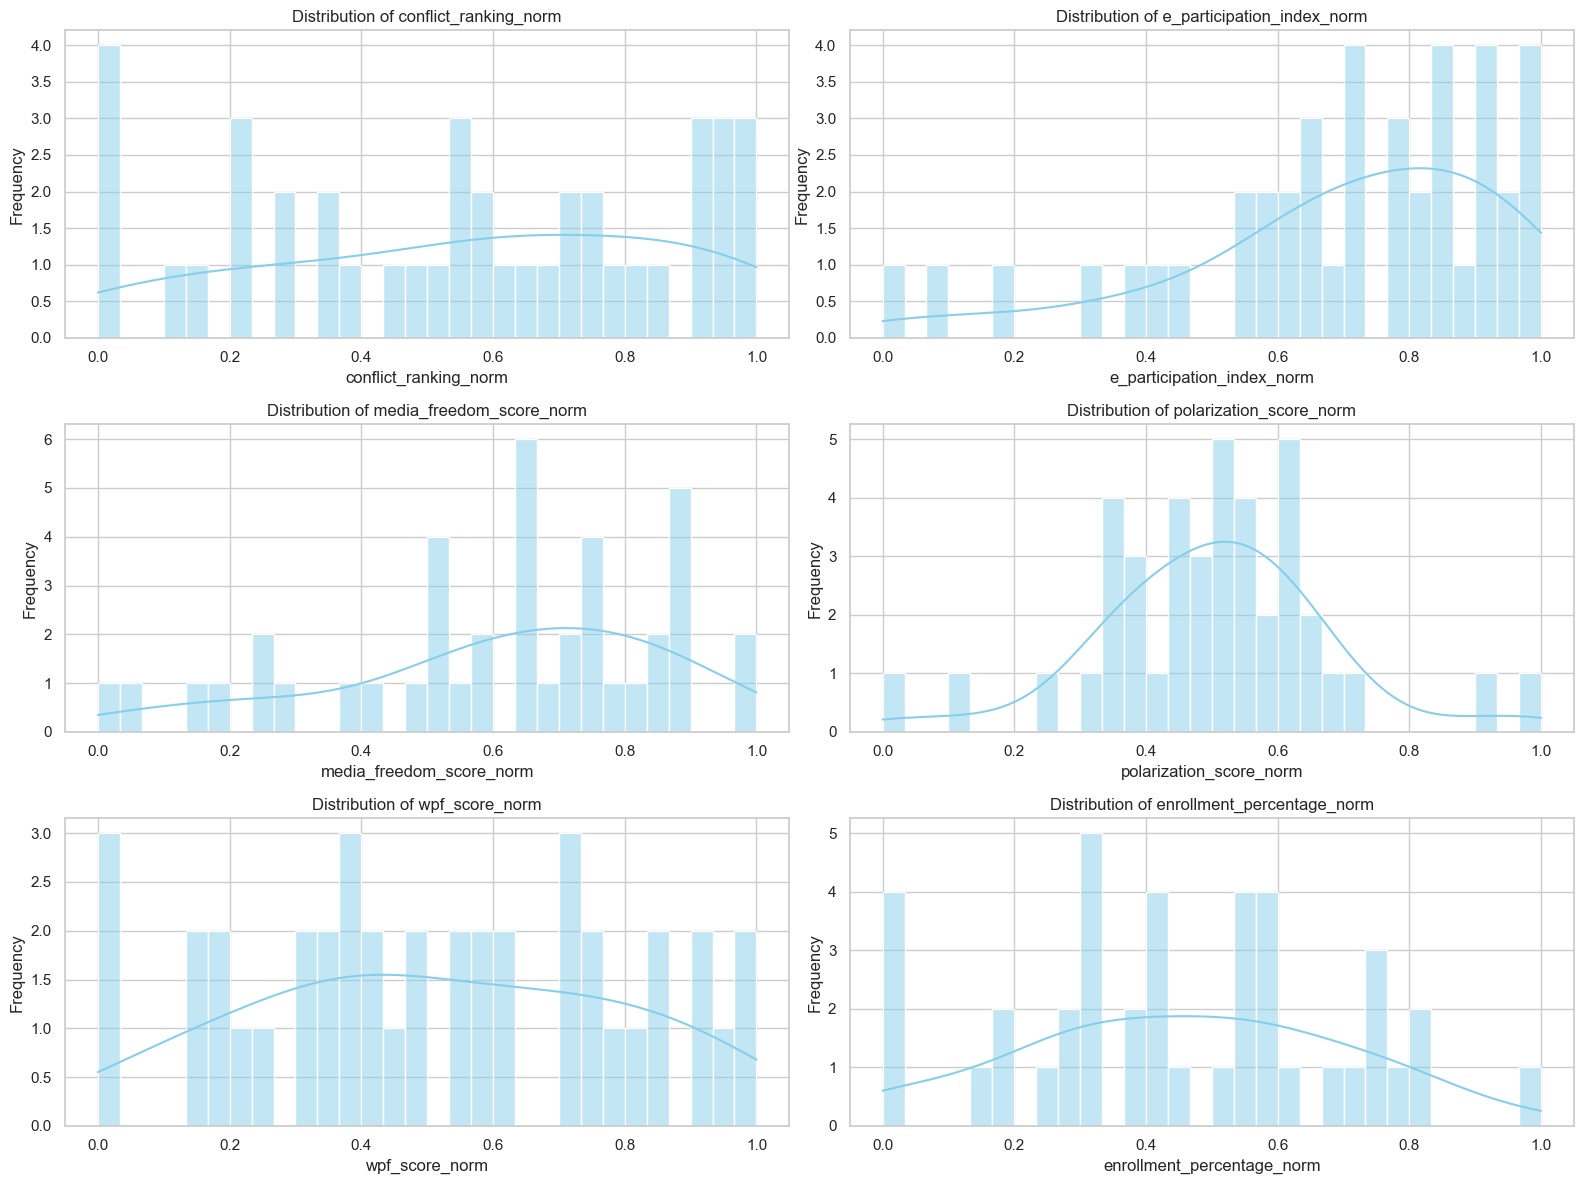

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# List of features to check
features = [
    "conflict_ranking_norm", 
    "e_participation_index_norm", 
    "media_freedom_score_norm",
    "polarization_score_norm", 
    "wpf_score_norm",
    "enrollment_percentage_norm"
]

# Create histograms for each feature
plt.figure(figsize=(16, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df_combined[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Bartlett's Test

In [50]:
import pandas as pd
from factor_analyzer import calculate_bartlett_sphericity

# Assuming df_transformed is your dataframe with the features used for PCA
# You can select the columns that are relevant for your PCA analysis
pca_columns = [
    "conflict_ranking_norm", 
    "e_participation_index_norm", 
    "media_freedom_score_norm",
    "polarization_score_norm", 
    "wpf_score_norm",
    "enrollment_percentage_norm"
]

# Extract the relevant columns from your dataframe
df_pca = df_combined[pca_columns]

# Perform Bartlett's test of sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(df_pca)

# Output the result
print(f'Bartlett’s Test of Sphericity: Chi-Square Value = {chi_square_value}, p-value = {p_value}')

# Interpret the result
if p_value < 0.05:
    print("Bartlett’s Test is significant. PCA is appropriate!")
else:
    print("Bartlett’s Test is not significant. PCA may not be appropriate.")

Bartlett’s Test of Sphericity: Chi-Square Value = 96.34226873014241, p-value = 6.41114447012182e-14
Bartlett’s Test is significant. PCA is appropriate!


# Scoring with PCA - With Regional Means for Imputing Missing Values

In [127]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the columns to include in PCA (normalized indicators only)
pca_columns = [
    "conflict_ranking_norm", "e_participation_index_norm", "media_freedom_score_norm",
    "polarization_score_norm", "wpf_score_norm",
    "enrollment_percentage_norm"]

# Drop any remaining missing values (there shouldn't be any if imputation succeeded)
pca_data = df_combined.dropna(subset=pca_columns)

# Standardize the data (mean=0, std=1) — better for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_data[pca_columns])

# Perform PCA
pca = PCA(n_components=2)
principal_components_2 = pca.fit_transform(X_scaled)

# Create DataFrame for results
pca_result_2 = pd.DataFrame(principal_components_2, columns=["PC1", "PC2"])
pca_result_2["country"] = pca_data["country"].values
pca_result_2["region"] = pca_data["region"].values


## PCA Plot - 2 PCs

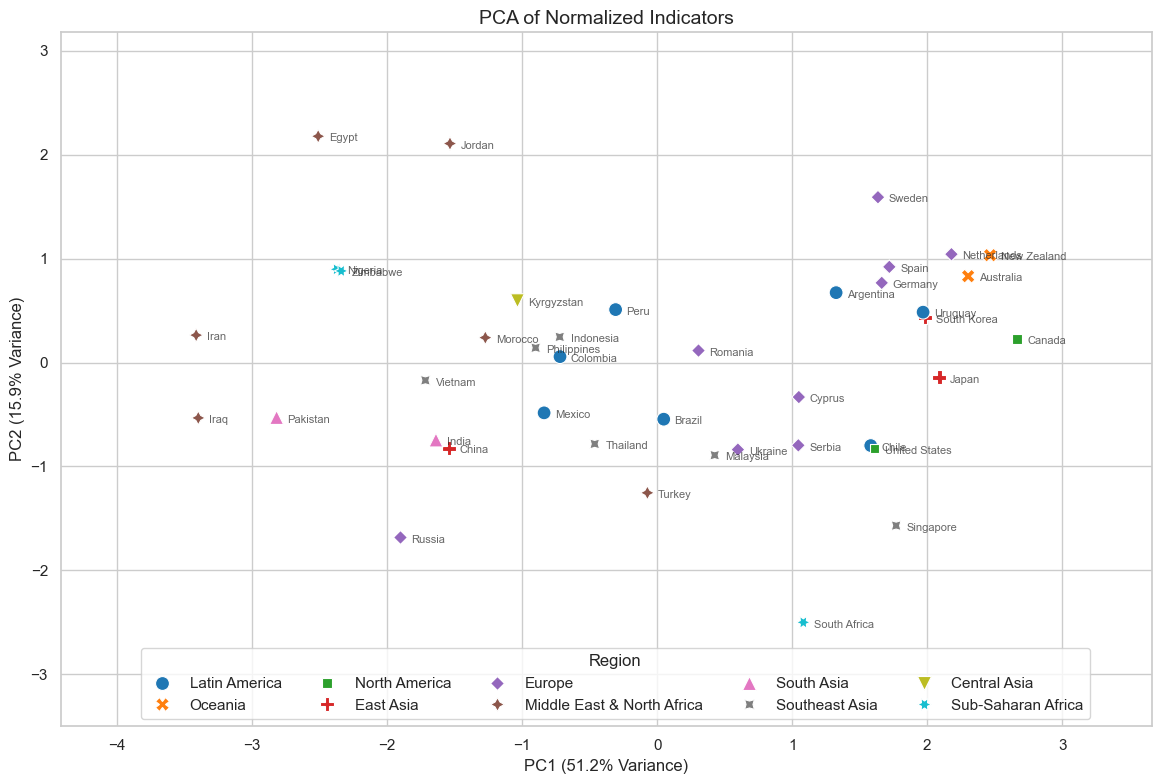

In [90]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_result_2, x="PC1", y="PC2", hue="region", style="region", s=100, palette="tab10")

# Annotate each point — label offset to bottom right
for i in range(pca_result_2.shape[0]):
    plt.text(
        pca_result_2["PC1"][i] + 0.08,
        pca_result_2["PC2"][i] - 0.05,
        pca_result_2["country"][i],
        fontsize=8,
        alpha=0.7
    )

plt.title("PCA of Normalized Indicators", fontsize=14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")

# Stretch axes for better layout
plt.xlim(pca_result_2["PC1"].min() - 1, pca_result_2["PC1"].max() + 1)
plt.ylim(pca_result_2["PC2"].min() - 1, pca_result_2["PC2"].max() + 1)

# Move and reshape legend (2 columns, bottom right)
plt.legend(
    title="Region",
    loc="lower right",
    bbox_to_anchor=(0.95, 0),
    ncol=5,  # 👈 Two columns here
    frameon=True
)

plt.grid(True)
plt.tight_layout()

In [91]:
print("Explained variance ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.2%}")

Explained variance ratio:
PC1: 51.16%
PC2: 15.86%


# Rank the countries based on PC1 + PC2

In [136]:
pca_result_2['misinformation_vulnerability_score'] = pca_result_2['PC1']

# Optional: If you'd like to incorporate PC2 into the rank, you can combine both components
# For example, a weighted average could be used (feel free to adjust the weights as needed)
pca_result_2['misinformation_vulnerability_score'] = pca_result_2['PC1'] * 0.5 + pca_result_2['PC2'] * 0.5

# Normalize the final vulnerability score to a scale of 0-1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
pca_result_2['misinformation_vulnerability_score_normalized'] = scaler.fit_transform(
    pca_result_2[['misinformation_vulnerability_score']]
)

# Rank countries based on their vulnerability score (higher score = higher vulnerability)
pca_result_2['rank'] = pca_result_2['misinformation_vulnerability_score_normalized'].rank(ascending=False)

# Display the top countries with the highest vulnerability scores
print(pca_result_2[['country', 'misinformation_vulnerability_score_normalized', 'rank']].sort_values(by='rank'))

## Add iso_code column to the PCA result
pca_result_2['iso_code'] = pca_data['iso_code'].values
cols = pca_result_2.columns.tolist()
cols.remove("iso_code")
cols.insert(cols.index("country") + 1, "iso_code")
pca_result = pca_result_2[cols]

# Save the PCA result with the vulnerability score
pca_result.to_csv("../data/reports/misinformation_index/pca_2_misinformation_vulnerability_scores.csv", index=False)



          country  misinformation_vulnerability_score_normalized  rank
21    New Zealand                                       1.000000   1.0
33         Sweden                                       0.963316   2.0
20    Netherlands                                       0.962766   3.0
1       Australia                                       0.950906   4.0
3          Canada                                       0.917964   5.0
32          Spain                                       0.884475   6.0
38        Uruguay                                       0.859396   7.0
9         Germany                                       0.856145   8.0
31    South Korea                                       0.854542   9.0
0       Argentina                                       0.797990  10.0
14          Japan                                       0.791205  11.0
37  United States                                       0.634430  12.0
4           Chile                                       0.634422  13.0
7     

/var/folders/vk/c6csf7ws6pj9wy406twfjkfw0000gn/T/ipykernel_51356/2309589513.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




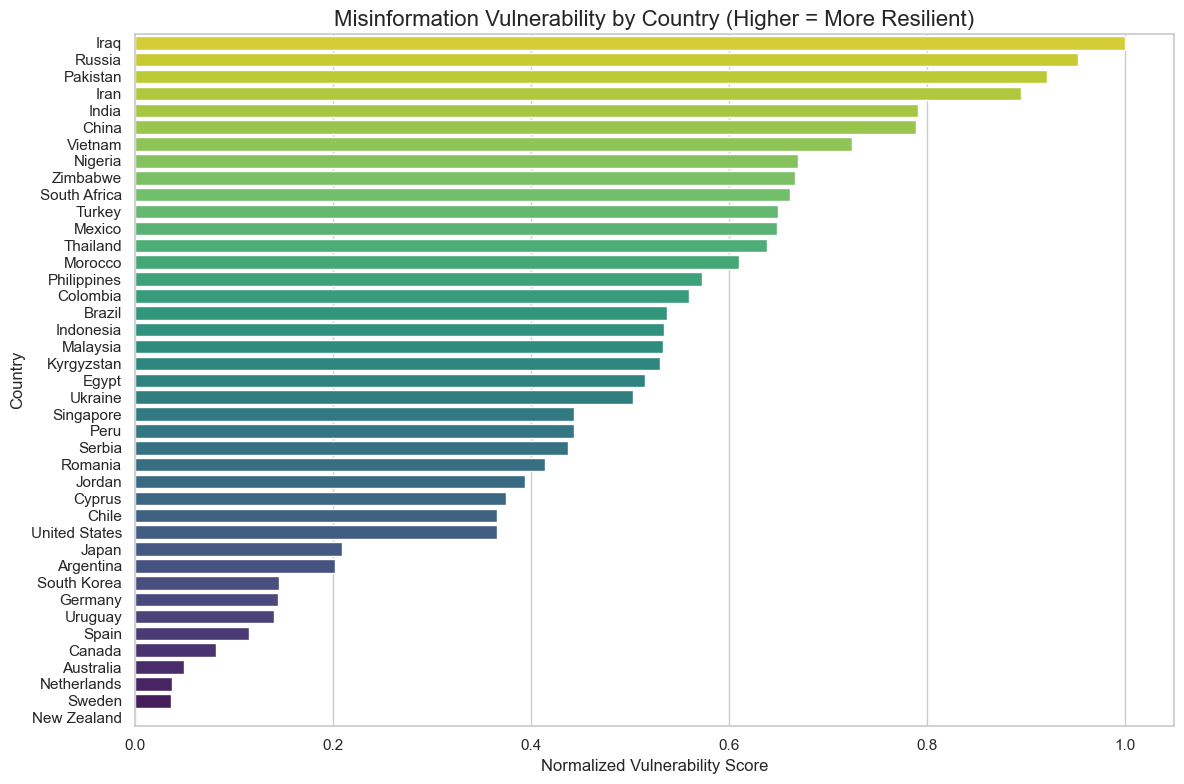

In [162]:
# Create a new inverted score (resilience)
pca_result_2['misinformation_resilience_score'] = 1 - pca_result_2['misinformation_vulnerability_score_normalized']

# Sort by original vulnerability score descending (most vulnerable at the top)
plot_data = pca_result_2.sort_values(by='misinformation_vulnerability_score_normalized', ascending=False)

# Plot the resilience score, but ensure the highest vulnerability countries are at the top
plt.figure(figsize=(12, 8))
sns.barplot(
    data=plot_data,
    y='country', 
    x='misinformation_resilience_score', 
    palette='viridis'
)

# Title and labels
plt.title('Misinformation Vulnerability by Country (Higher = More Resilient)', fontsize=16)
plt.xlabel('Normalized Vulnerability Score')
plt.ylabel('Country')

# Invert the y-axis to make the highest vulnerability at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()



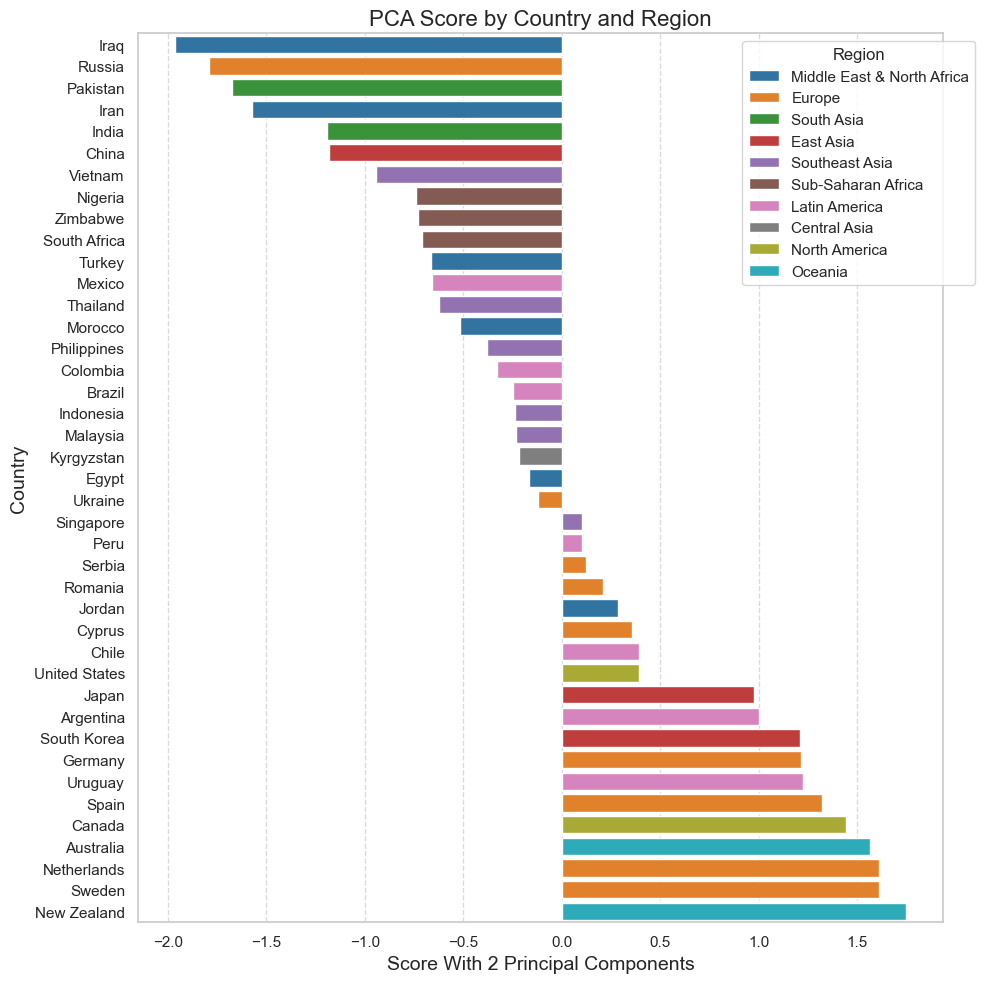

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assume pca_result_2 is ready

if pca_result_2.empty:
    raise ValueError("pca_result_2 is empty. Please check the data.")

# Create the combined PCA score
pca_result_2['pca_score'] = 0.5 * pca_result_2['PC1'] + 0.5 * pca_result_2['PC2']

# Sort by pca_score (optional, for prettier plotting)
pca_result_2 = pca_result_2.sort_values('pca_score', ascending=True)

# Plot
plt.figure(figsize=(10, 10))
sns.barplot(
    data=pca_result_2,
    x='pca_score',
    y='country',
    hue='region',
    dodge=False,
    palette='tab10',
    orient='h'
)

# Titles and labels
plt.title("PCA Score by Country and Region", fontsize=16)
plt.xlabel("Score With 2 Principal Components", fontsize=14)
plt.ylabel("Country", fontsize=14)

# Legend
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


# 3 Principal Components

In [156]:
#### With 3 PCAs


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the columns to include in PCA (normalized indicators only)
pca_columns = [
    "conflict_ranking_norm", "e_participation_index_norm", "media_freedom_score_norm",
    "polarization_score_norm", "wpf_score_norm",
    "enrollment_percentage_norm"]

# Drop any remaining missing values
pca_data = df_combined.dropna(subset=pca_columns)

# Standardize the data (mean=0, std=1) — important for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_data[pca_columns])

# Perform PCA with 3 components
pca = PCA(n_components=3)
principal_components_3 = pca.fit_transform(X_scaled)

# Create DataFrame for results
pca_result_3 = pd.DataFrame(principal_components_3, columns=["PC1", "PC2", "PC3"])
pca_result_3["country"] = pca_data["country"].values
pca_result_3["region"] = pca_data["region"].values

# Optionally, preview the result
print(pca_result_3.head())

        PC1       PC2       PC3    country         region
0  1.325146  0.672931 -0.107704  Argentina  Latin America
1  2.302758  0.831476 -0.361611  Australia        Oceania
2  0.048624 -0.544796  0.868657     Brazil  Latin America
3  2.663683  0.225793  0.457513     Canada  North America
4  1.581622 -0.798833  0.430712      Chile  Latin America


In [123]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Create a DataFrame for easier reading
explained_variance_df = pd.DataFrame({
    'Principal Component': ['PC1', 'PC2', 'PC3'],
    'Explained Variance Ratio': explained_variance
})

print(explained_variance_df)

  Principal Component  Explained Variance Ratio
0                 PC1                  0.511629
1                 PC2                  0.158635
2                 PC3                  0.143849


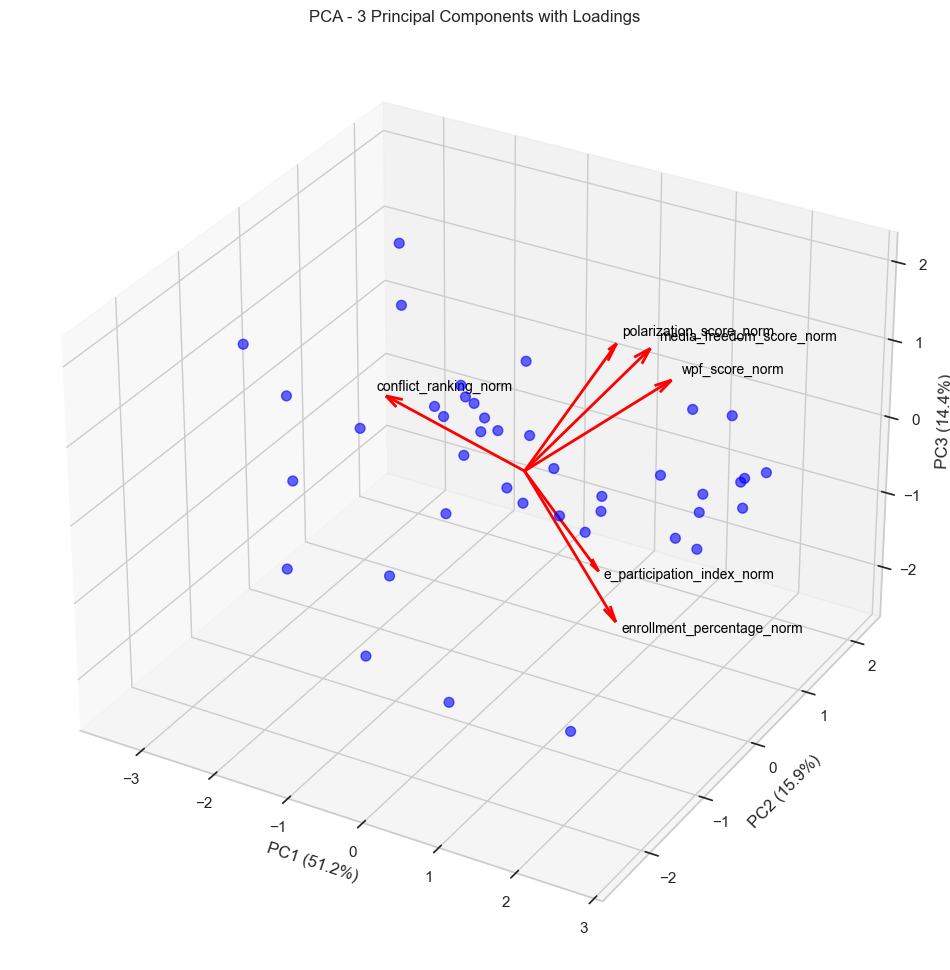

In [158]:
loadings = pca.components_.T

from mpl_toolkits.mplot3d import Axes3D

# Get explained variance ratios
explained_variance = pca.explained_variance_ratio_ * 100

# Get loadings
loadings = pca.components_.T  # shape: (features, components)
feature_names = pca_columns  # assuming you defined this earlier

fig = plt.figure(figsize=(12, 15))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the countries
ax.scatter(pca_result_3['PC1'], pca_result_3['PC2'], pca_result_3['PC3'],
           c='blue', s=50, alpha=0.6)

# Set axis labels with variance explained
ax.set_xlabel(f'PC1 ({explained_variance[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_variance[2]:.1f}%)')
ax.set_title('PCA - 3 Principal Components with Loadings')

# Add the feature vectors (loadings)
for i, feature in enumerate(feature_names):
    ax.quiver(0, 0, 0,                # origin point
              loadings[i, 0]*3,        # scale for visualization
              loadings[i, 1]*3,
              loadings[i, 2]*3,
              color='red', 
              linewidth=2, 
              arrow_length_ratio=0.1)
    ax.text(loadings[i, 0]*3.2, loadings[i, 1]*3.2, loadings[i, 2]*3.2, 
            feature, color='black', fontsize=10)

plt.show()

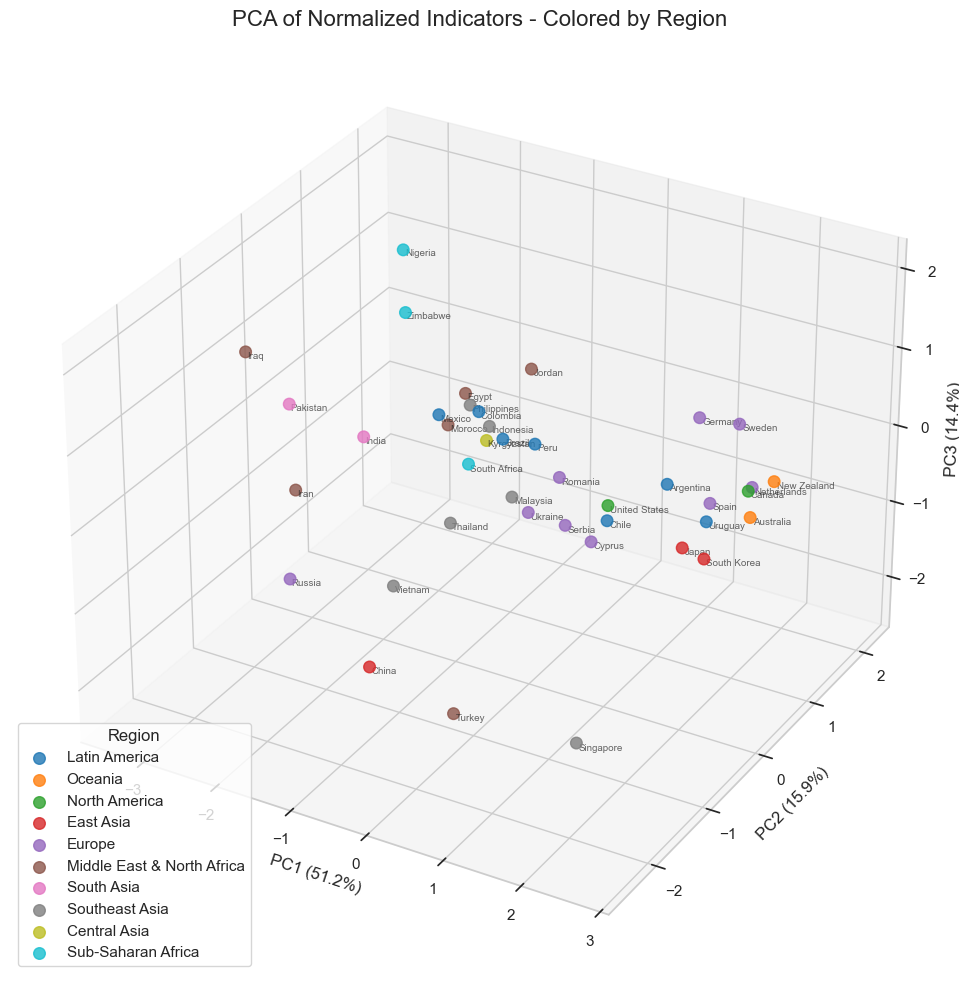

In [163]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare figure
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Create a color palette based on regions
unique_regions = pca_result_3['region'].unique()
palette = sns.color_palette("tab10", n_colors=len(unique_regions))
region_colors = dict(zip(unique_regions, palette))

# Plot each region separately
for region in unique_regions:
    region_data = pca_result_3[pca_result_3['region'] == region]
    ax.scatter(
        region_data['PC1'],
        region_data['PC2'],
        region_data['PC3'],
        label=region,
        s=70,
        alpha=0.8,
        color=region_colors[region]
    )
    # Annotate countries
    for i in range(region_data.shape[0]):
        ax.text(
            region_data['PC1'].values[i] + 0.1,
            region_data['PC2'].values[i] - 0.1,
            region_data['PC3'].values[i],
            region_data['country'].values[i],
            fontsize=7,
            alpha=0.7
        )

# Axis labels with explained variance
explained_variance = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({explained_variance[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_variance[2]:.1f}%)')

ax.set_title('PCA of Normalized Indicators - Colored by Region', fontsize=16)
ax.legend(
    title="Region",
    loc="lower left",
    bbox_to_anchor=(0.0, 0.0),
    frameon=True
)

ax.grid(True)
plt.tight_layout()
plt.show()

## Ranking with 3 PC's

In [110]:
# Automatically weighted score
explained_variance = pca.explained_variance_ratio_

pca_result['pca_score'] = (
    pca_result['PC1'] * explained_variance[0] +
    pca_result['PC2'] * explained_variance[1] +
    pca_result['PC3'] * explained_variance[2]
)
pca_result['pca_rank'] = pca_result['pca_score'].rank(ascending=False)

# Show the countries listed by their PCA score
print(pca_result[['country', 'pca_score', 'pca_rank']].sort_values(by='pca_rank'))

          country  pca_score  pca_rank
3          Canada   1.464448       1.0
21    New Zealand   1.427939       2.0
20    Netherlands   1.259985       3.0
1       Australia   1.258041       4.0
33         Sweden   1.115661       5.0
9         Germany   1.084098       6.0
38        Uruguay   1.042633       7.0
14          Japan   1.019491       8.0
31    South Korea   0.978509       9.0
32          Spain   0.968277      10.0
37  United States   0.785268      11.0
0       Argentina   0.769240      12.0
4           Chile   0.744438      13.0
30   South Africa   0.452399      14.0
7          Cyprus   0.442867      15.0
28         Serbia   0.440040      16.0
29      Singapore   0.394182      17.0
36        Ukraine   0.213534      18.0
26        Romania   0.181462      19.0
17       Malaysia   0.142902      20.0
2          Brazil   0.063409      21.0
24           Peru  -0.067853      22.0
6        Colombia  -0.266778      23.0
11      Indonesia  -0.281456      24.0
25    Philippines  -0.348

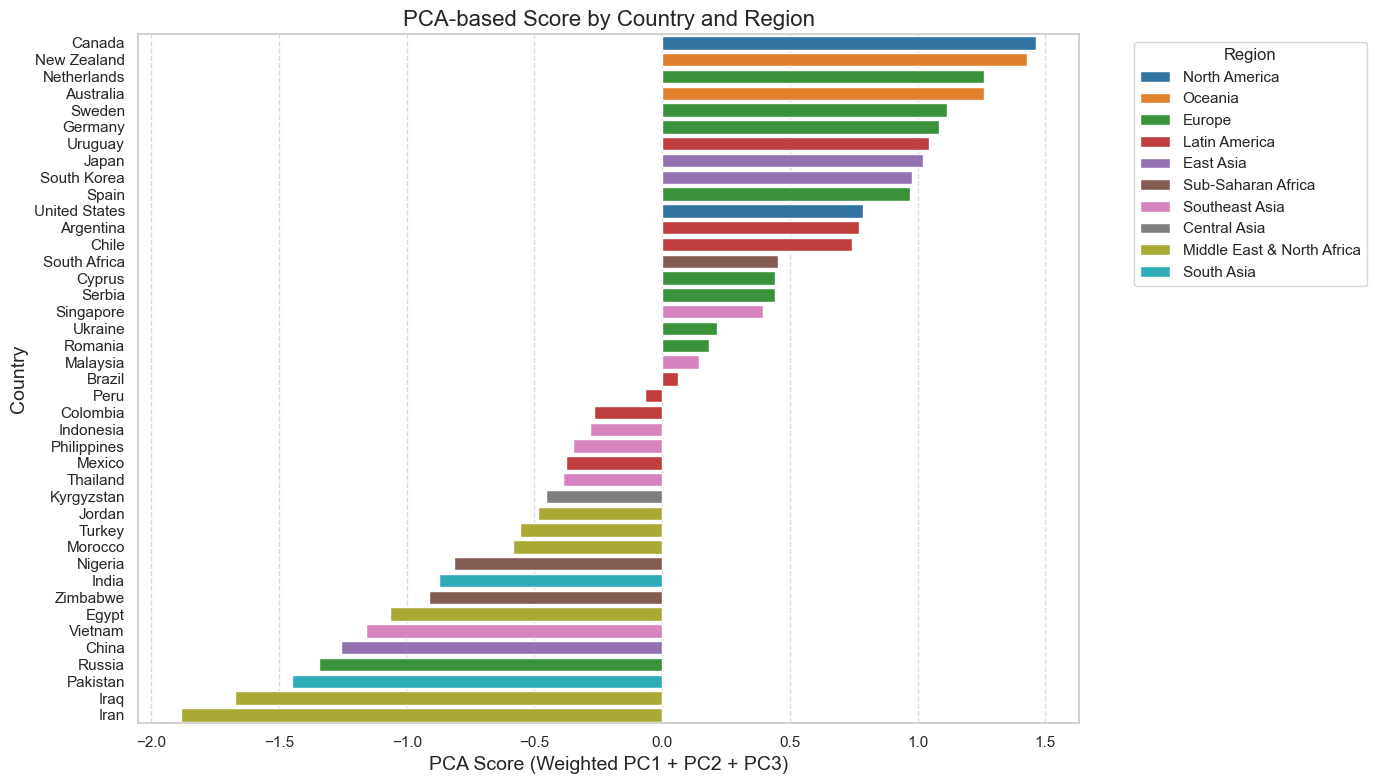

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the results by the pca_score (higher is better)
pca_result_sorted = pca_result.sort_values('pca_score', ascending=False)

# Set up the plot
plt.figure(figsize=(14, 8))
sns.barplot(
    data=pca_result_sorted,
    x='pca_score',
    y='country',
    hue='region',
    dodge=False,
    palette='tab10'
)

# Titles and labels
plt.title('PCA-based Score by Country and Region', fontsize=16)
plt.xlabel('PCA Score (Weighted PC1 + PC2 + PC3)', fontsize=14)
plt.ylabel('Country', fontsize=14)

# Make it pretty
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the results by pca_score, ascending (more negative first)
pca_result_sorted = pca_result.sort_values('pca_score', ascending=True)

# Set up the plot
plt.figure(figsize=(14, 8))
sns.barplot(
    data=pca_result_sorted,
    x='pca_score',
    y='country',
    hue='region',
    dodge=False,
    palette='tab10',
    orient='h'   # Horizontal bars, for easier comparison
)

# Titles and labels
plt.title('PCA-based Score by Country and Region', fontsize=16)
plt.xlabel('PCA Score (Weighted PC1 + PC2 + PC3)', fontsize=14)
plt.ylabel('Country', fontsize=14)

# Make it pretty
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

KeyError: 'pca_score'

## Map Visualisation

In [135]:
import pandas as pd
import plotly.express as px

# Create the choropleth map using ISO country codes
fig = px.choropleth(
    pca_result, 
    locations='iso_code',  # Use the ISO country codes for mapping
    color='misinformation_vulnerability_score_normalized',  # Use the normalized vulnerability score
    hover_name='country',  # Show country name on hover
    color_continuous_scale='Viridis',  # Reversed color scale for the map (higher scores = more vulnerable)
    labels={'misinformation_vulnerability_score_normalized': 'Vulnerability Score'},
    title='Misinformation Vulnerability by Country (Higher Score = More Vulnerable)',
    range_color=[pca_result['misinformation_vulnerability_score_normalized'].min(), pca_result['misinformation_vulnerability_score_normalized'].max()]  # Explicitly setting color range
)

# Update layout to make the map non-interactive (static)
fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="lightgray")

# Show the plot (static map)
fig.show()